# Berka — alternative conditional-dispersion families (future-work companion)

Companion notebook to `paper/Transactions/logit_normal_companion.md` (the planning doc for the numerical $P(m)$, $P(w)$ derivations under non-Beta-Binomial conditional dispersion).

This notebook houses the **exploratory** content that wouldn't fit in the PRL submission's empirical baseline:

- F1, F2 — empirical $p(q)$ and per-account $\langle q_i \rangle$ distributions (kept here as the foundation the rest builds on)
- F2b — within-account residuals $r = q - \langle q_i \rangle$ + variance decomposition
- F2c — moment-match $\hat\xi$ for the paper's Beta-Binomial conditional
- F2d — empirical residuals vs Beta-Binomial overlay (and Poisson, the literature null)
- F2e — alternative conditional shapes (truncated Gaussian, truncated Laplace, logit-normal) at matched per-account variance
- F2f — same alternatives, each fit individually
- F2g — per-account variance scaling, with each fitted family's prediction (slopes 0/1/2 on log-log)

Empirical headline (see F2g): the Berka cloud's free-slope is α ≈ 1.87 (all debits) / 1.64 (voluntary), much closer to logit-normal's slope-2 prediction than Beta's slope-1. The companion `.md` lays out what this means for the SM derivations.

The PRL-baseline notebook lives at `berka/empirical_analysis.ipynb` — that one stays close to the paper's existing format (Poisson as the only model comparison) and produces the calibration numbers for the simulator.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

DATA_DIR = 'berka-dataset'
TX_PATH = os.path.join(DATA_DIR, 'trans-clean-eng.asc')

VOLUNTARY_CATEGS = {'Withdrawal', 'Transfer', 'Card Payment'}

plt.rcParams.update({'figure.dpi': 100, 'axes.labelsize': 12, 'legend.fontsize': 10})

In [2]:
def histogram(values, num_bins=30, log_bin=False, density=True):
    """Return (bin_centers, density) for a 1D array. Mirrors the helper in the Sarafu notebook."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if log_bin:
        v = v[v > 0]
        if v.size == 0:
            return np.array([]), np.array([])
        edges = np.logspace(np.log10(v.min()), np.log10(v.max()), num_bins + 1)
    else:
        if v.size == 0:
            return np.array([]), np.array([])
        edges = np.linspace(v.min(), v.max(), num_bins + 1)
    counts, edges = np.histogram(v, bins=edges, density=density)
    if log_bin:
        centers = np.sqrt(edges[:-1] * edges[1:])
    else:
        centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts

## Load and preprocess

Build a `berka` dict that mirrors the structure of the `sarafu` dict in the student's notebook (`transactions`, `agents`, `balance_pivot`, `filtered_balances`) so figure code is portable.

In [3]:
tx = pd.read_csv(
    TX_PATH, sep=';',
    dtype={'trans_id': 'int64', 'account_id': 'int32', 'date': 'string',
           'type': 'category', 'amount': 'float64', 'balance': 'float64',
           'bank': 'string', 'account': 'string', 'value': 'float64',
           'categ': 'category', 'detail': 'string'},
)
tx['date'] = pd.to_datetime(tx['date'], format='%y%m%d')
tx = tx.sort_values(['account_id', 'date', 'trans_id']).reset_index(drop=True)
tx['pre_balance'] = tx['balance'] - tx['value']
print(f'{len(tx):,} transactions across {tx.account_id.nunique():,} accounts; {tx.date.min().date()} – {tx.date.max().date()}')
tx.head()

1,056,320 transactions across 4,500 accounts; 1993-01-01 – 1998-12-31


,trans_id,account_id,date,type,amount,balance,bank,account,value,categ,detail,pre_balance
0,1,1,1995-03-24,CREDIT,1000.0,1000.0,<NA>,<NA>,1000.0,Deposit,<NA>,0.0
1,5,1,1995-04-13,CREDIT,3679.0,4679.0,AB,41403269,3679.0,Transfer,<NA>,1000.0
2,199,1,1995-04-23,CREDIT,12600.0,17279.0,<NA>,<NA>,12600.0,Deposit,<NA>,4679.0
3,3530438,1,1995-04-30,CREDIT,19.2,17298.2,<NA>,<NA>,19.2,Fee,Interest,17279.0
4,6,1,1995-05-13,CREDIT,3679.0,20977.2,AB,41403269,3679.0,Transfer,<NA>,17298.2


In [4]:
is_debit = tx['type'].eq('DEBIT')
is_credit = tx['type'].eq('CREDIT')

tx['frac_out'] = np.where(is_debit & (tx['pre_balance'] > 0),
                          tx['amount'] / tx['pre_balance'], np.nan)
tx['frac_in'] = np.where(is_credit & (tx['pre_balance'] >= 0),
                         tx['amount'] / (tx['pre_balance'] + tx['amount']), np.nan)
tx['voluntary'] = is_debit & tx['categ'].isin(VOLUNTARY_CATEGS)

n_overdraft = (tx['frac_out'] > 1).sum()
tx.loc[tx['frac_out'] > 1, 'frac_out'] = np.nan
print(f'frac_out defined on {tx["frac_out"].notna().sum():,} debits ({n_overdraft:,} overdrafts dropped)')
print(f'voluntary debits: {tx["voluntary"].sum():,}')

frac_out defined on 648,839 debits (869 overdrafts dropped)
voluntary debits: 493,828


In [5]:
amt_credit = tx['amount'].where(tx['type'].eq('CREDIT'), 0.0)
amt_debit  = tx['amount'].where(tx['type'].eq('DEBIT'),  0.0)
n_credit   = tx['type'].eq('CREDIT').astype('int32')
n_debit    = tx['type'].eq('DEBIT').astype('int32')
frac_vol   = tx['frac_out'].where(tx['voluntary'])

agents = pd.DataFrame({
    'vol_in':  amt_credit.groupby(tx['account_id'], observed=True).sum(),
    'vol_out': amt_debit.groupby(tx['account_id'], observed=True).sum(),
    'tx_in':   n_credit.groupby(tx['account_id'], observed=True).sum(),
    'tx_out':  n_debit.groupby(tx['account_id'], observed=True).sum(),
    'mean_frac_out_all':       tx.groupby('account_id', observed=True)['frac_out'].mean(),
    'mean_frac_out_voluntary': frac_vol.groupby(tx['account_id'], observed=True).mean(),
    'initial_bal': tx.groupby('account_id', observed=True)['balance'].first(),
    'final_bal':   tx.groupby('account_id', observed=True)['balance'].last(),
    'min_bal':     tx.groupby('account_id', observed=True)['balance'].min(),
    'mean_bal':    tx.groupby('account_id', observed=True)['balance'].mean(),
    'first_date':  tx.groupby('account_id', observed=True)['date'].first(),
    'last_date':   tx.groupby('account_id', observed=True)['date'].last(),
})
print(agents.shape)
agents.head()

(4500, 12)


,vol_in,vol_out,tx_in,tx_out,mean_frac_out_all,mean_frac_out_voluntary,initial_bal,final_bal,min_bal,mean_bal,first_date,last_date
account_id,,,,,,,,,,,,
1,194320.5,180854.0,102,137,0.078942,0.111116,1000.0,13466.5,1000.0,15994.008368,1995-03-24,1998-12-31
2,1597053.5,1554425.8,152,326,0.123065,0.153604,1100.0,42628.1,1100.0,36540.704393,1993-02-26,1998-12-31
3,173059.0,121962.8,46,71,0.069980,0.085537,1000.0,51096.1,1000.0,26973.506838,1997-07-07,1998-12-31
4,192346.0,158625.4,65,121,0.059758,0.078375,800.0,33720.7,800.0,21753.446237,1996-02-21,1998-12-31
5,97485.0,69396.4,35,49,0.052975,0.073941,600.0,28088.3,600.0,25090.069048,1997-05-30,1998-12-31


In [6]:
account = pd.read_csv(os.path.join(DATA_DIR, 'account.asc'), sep=';')
disp    = pd.read_csv(os.path.join(DATA_DIR, 'disp.asc'),    sep=';')
client  = pd.read_csv(os.path.join(DATA_DIR, 'client.asc'),  sep=';', dtype={'birth_number': 'string'})
district = pd.read_csv(os.path.join(DATA_DIR, 'district.asc'), sep=';')

owners = disp[disp['type'] == 'OWNER'].merge(client, on='client_id', how='left')
bn = owners['birth_number'].str.zfill(6)
month = bn.str[2:4].astype(int)
owners['gender'] = np.where(month > 50, 'F', 'M')
owners = owners[['account_id', 'gender']]

district = district.rename(columns={'A1': 'district_id', 'A3': 'region', 'A8': 'city_category', 'A10': 'avg_salary_pct'})
acct_meta = (account[['account_id', 'district_id']]
             .merge(district[['district_id', 'region', 'city_category', 'avg_salary_pct']], on='district_id', how='left')
             .merge(owners, on='account_id', how='left'))
agents = agents.join(acct_meta.set_index('account_id'))
agents.head()

,vol_in,vol_out,tx_in,tx_out,mean_frac_out_all,mean_frac_out_voluntary,initial_bal,final_bal,min_bal,mean_bal,first_date,last_date,district_id,region,city_category,avg_salary_pct,gender
account_id,,,,,,,,,,,,,,,,,
1,194320.5,180854.0,102,137,0.078942,0.111116,1000.0,13466.5,1000.0,15994.008368,1995-03-24,1998-12-31,18,south Bohemia,1,65.3,F
2,1597053.5,1554425.8,152,326,0.123065,0.153604,1100.0,42628.1,1100.0,36540.704393,1993-02-26,1998-12-31,1,Prague,1,100.0,M
3,173059.0,121962.8,46,71,0.069980,0.085537,1000.0,51096.1,1000.0,26973.506838,1997-07-07,1998-12-31,5,central Bohemia,1,51.4,M
4,192346.0,158625.4,65,121,0.059758,0.078375,800.0,33720.7,800.0,21753.446237,1996-02-21,1998-12-31,12,central Bohemia,1,58.0,M
5,97485.0,69396.4,35,49,0.052975,0.073941,600.0,28088.3,600.0,25090.069048,1997-05-30,1998-12-31,15,south Bohemia,1,51.9,M


In [7]:
eod = (tx.groupby(['account_id', 'date'])['balance'].last()
         .unstack('account_id').sort_index())
full_idx = pd.date_range(eod.index.min(), eod.index.max(), freq='D')
balance_pivot = eod.reindex(full_idx).ffill().T
balance_pivot.index.name = 'account_id'
balance_pivot.columns.name = 'date'
print(f'balance_pivot: {balance_pivot.shape[0]:,} accounts × {balance_pivot.shape[1]:,} days')

fb = balance_pivot.stack().rename('balance').reset_index()
filtered_balances = fb[fb['balance'] >= 1].copy()
print(f'filtered_balances: {len(filtered_balances):,} (account, day) cells with balance ≥ 1')

balance_pivot: 4,500 accounts × 2,191 days
filtered_balances: 5,568,772 (account, day) cells with balance ≥ 1


In [8]:
berka = {
    'transactions':       tx,
    'agents':             agents,
    'balance_pivot':      balance_pivot,
    'filtered_balances':  filtered_balances,
}

# Sanity checks
assert berka['agents'].shape[0] == 4500, berka['agents'].shape
f = berka['transactions']['frac_out'].dropna()
assert f.between(0, 1).all(), (f.min(), f.max())

# Flow identity: vol_in - vol_out should equal final_bal - first_pre_balance, summed across accounts.
# Within-day reordering during the cleaning pass leaves small residuals (the cleaning notebook noted
# <0.01% rows with > 1 crown error); accept up to 1% on the cross-account sum.
first_value = tx.groupby('account_id', observed=True)['value'].first()
identity_lhs = agents['vol_in'].sum() - agents['vol_out'].sum()
identity_rhs = (agents['final_bal'] - (agents['initial_bal'] - first_value)).sum()
rel_err = abs(identity_lhs - identity_rhs) / abs(identity_lhs)
print(f'flow identity rel-error: {rel_err:.2%}')
assert rel_err < 0.01, (identity_lhs, identity_rhs)

flow identity rel-error: 0.43%


## F1 — Distribution of per-transaction `frac_out`

Sarafu Group 2 (Figs 3–5). Two panels: (left) all DEBIT transactions, (right) voluntary outflows only — isolating the effect of fees and standing orders.

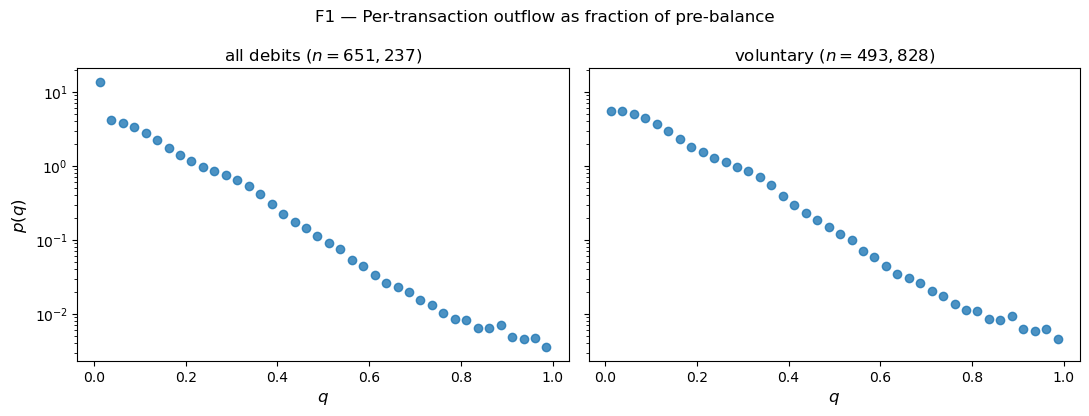

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, mask) in zip(axes, [
    ('all debits', tx['type'].eq('DEBIT')),
    ('voluntary',  tx['voluntary']),
]):
    centers, dens = histogram(tx.loc[mask, 'frac_out'], num_bins=40, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.8, color='C0')
    ax.set_xlabel(r'$q$')
    ax.set_title(f'{label} ($n={mask.sum():,}$)')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$p(q)$')
fig.suptitle('F1 — Per-transaction outflow as fraction of pre-balance')
fig.tight_layout()

## F2 — Distribution of per-account mean `frac_out`

Sarafu Group 3 (Figs 6–8). Per-agent characteristic spending propensity, again with the all-vs-voluntary split.

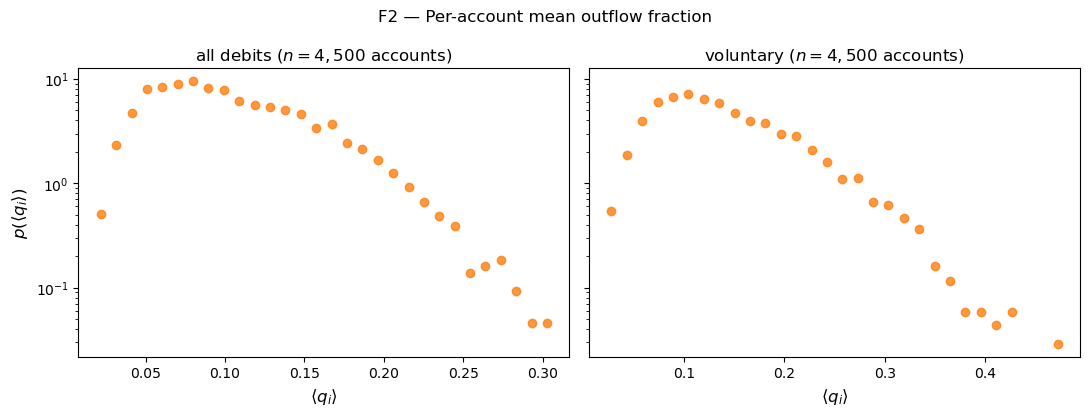

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, col) in zip(axes, [
    ('all debits', 'mean_frac_out_all'),
    ('voluntary',  'mean_frac_out_voluntary'),
]):
    vals = agents[col].dropna()
    centers, dens = histogram(vals, num_bins=30, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.8, color='C1')
    ax.set_xlabel(r'$\langle q_i \rangle$')
    ax.set_title(f'{label} ($n={len(vals):,}$ accounts)')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$p(\langle q_i \rangle)$')
fig.suptitle('F2 — Per-account mean outflow fraction')
fig.tight_layout()

## F2b — Within-account residuals $r_{ij} = q_{ij} - \langle q_i \rangle$

The transaction-level distribution F1 is a mixture of (a) between-account variation in mean propensity ⟨q_i⟩ (= F2) and (b) within-account variation around each account's mean. F2b isolates (b): for each transaction, subtract the owner account's own mean q. The annotated variance decomposition splits Var(q) = Var(⟨q_i⟩) + E[Var(q|i)] into between- and within-account contributions.

(Symbol note: this residual is just $q - \langle q_i \rangle$. We avoid the symbol ξ here because the paper uses ξ for the Beta-Binomial precision parameter — that's the next cell, F2c.)

all debits: Var(q)=0.0143  ->  between=0.0021 (14%)  within=0.0130 (86%)
voluntary : Var(q)=0.0146  ->  between=0.0039 (26%)  within=0.0112 (74%)


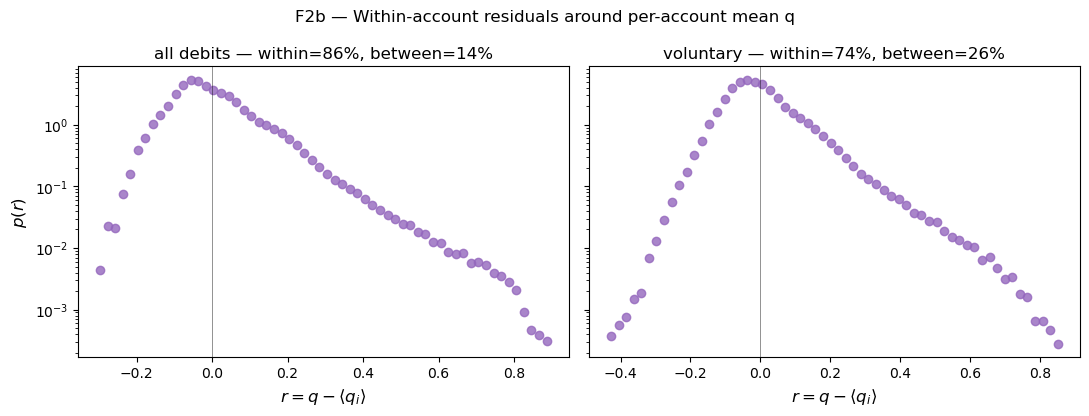

In [11]:
def residuals_and_decomp(q_series, account_ids):
    """Return (r, between_var, within_var) where r_ij = q_ij - <q_i>."""
    mask = q_series.notna()
    q = q_series[mask]
    a = account_ids[mask]
    mean_per = q.groupby(a, observed=True).transform('mean')
    r = (q - mean_per).rename('r')
    between = mean_per.var()
    within  = q.groupby(a, observed=True).var().mean()
    return r, between, within

q_all = tx['frac_out']
q_vol = tx['frac_out'].where(tx['voluntary'])

r_all, b_all, w_all = residuals_and_decomp(q_all, tx['account_id'])
r_vol, b_vol, w_vol = residuals_and_decomp(q_vol, tx['account_id'])

print(f"all debits: Var(q)={q_all.var():.4f}  ->  between={b_all:.4f} ({b_all/(b_all+w_all):.0%})  within={w_all:.4f} ({w_all/(b_all+w_all):.0%})")
print(f"voluntary : Var(q)={q_vol.var():.4f}  ->  between={b_vol:.4f} ({b_vol/(b_vol+w_vol):.0%})  within={w_vol:.4f} ({w_vol/(b_vol+w_vol):.0%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, r, b, w) in zip(axes, [
    ('all debits', r_all, b_all, w_all),
    ('voluntary',  r_vol, b_vol, w_vol),
]):
    centers, dens = histogram(r, num_bins=60, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.8, color='C4')
    ax.axvline(0, color='k', lw=0.6, alpha=0.5)
    frac_within = w / (b + w)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_title(f"{label} — within={frac_within:.0%}, between={1-frac_within:.0%}")
    ax.set_yscale('log')
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle('F2b — Within-account residuals around per-account mean q')
fig.tight_layout()

## F2c — Estimate the Beta-Binomial precision parameter $\xi$

Under the paper's BetaBin model, transactions for an account with balance $m$ and propensity $s$ have $w \sim \mathrm{BetaBin}(m, \xi s, \xi(1-s))$, giving (SM Eq. for $\sigma^2$, large-$m$ limit)
$$\mathrm{Var}(q_{ij}\mid i) \;\approx\; \frac{s_i(1-s_i)}{\xi+1}.$$
So the within-account variance of $q$ should be a linear function of $s_i(1-s_i)$ with slope $1/(\xi+1)$, *and that slope should be the same for every account*. Two checks:

1. **Moment-matching estimate**: $\hat\xi = \mathbb{E}_i[s_i(1-s_i)] / \mathbb{E}_i[\mathrm{Var}(q\mid i)] - 1$, computed on accounts with enough debits (≥ 20) for the per-account variance to be stable.
2. **Per-account scatter** of $\mathrm{Var}(q\mid i)$ vs $s_i(1-s_i)$: if the model holds, points lie on a line through the origin. The line for the moment-matched $\hat\xi$ is overlaid; deviations would indicate $\xi$ varies across accounts (or the BetaBin form is wrong).

For comparison, the paper calibrates $\xi=1$ on Sarafu (low precision / heavy within-account dispersion).

all debits  (n>=20, 4,409 accounts):  E[s(1-s)]=0.0886  E[Var(q|i)]=0.0123  -> xi_hat = 6.20
voluntary   (n>=20, 4,346 accounts):  E[s(1-s)]=0.1111  E[Var(q|i)]=0.0108  -> xi_hat = 9.26
(paper calibrates xi=1 on Sarafu)


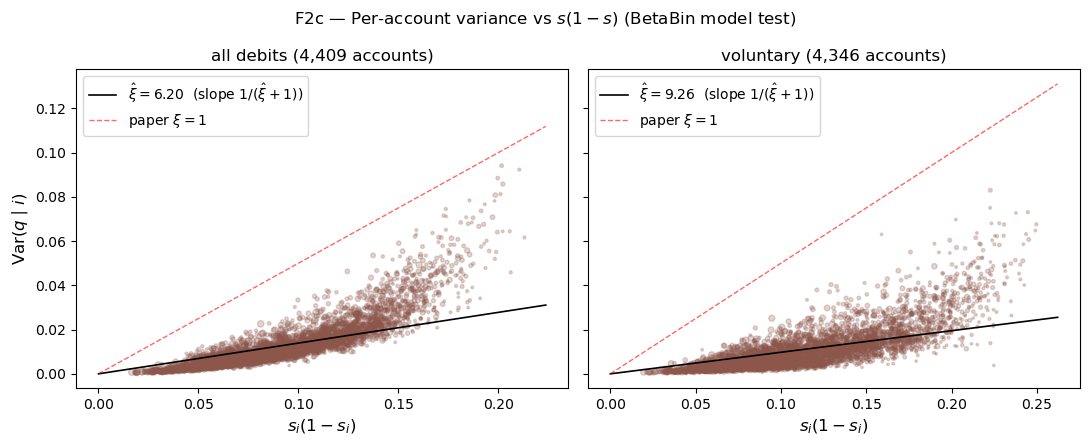

In [12]:
def per_account_moments(q_series, account_ids, min_n=20):
    """Per-account mean s_i, variance Var(q|i), count n_i. Drops accounts with n_i < min_n."""
    mask = q_series.notna()
    q = q_series[mask]
    a = account_ids[mask]
    g = q.groupby(a, observed=True)
    df = pd.DataFrame({'s': g.mean(), 'var': g.var(ddof=1), 'n': g.size()})
    return df[df['n'] >= min_n]

def estimate_xi(per_acct):
    """Moment-matching: E[s(1-s)] / E[Var(q|i)] - 1. Weighted by n_i for stability."""
    w = per_acct['n']
    e_s1ms = np.average(per_acct['s'] * (1 - per_acct['s']), weights=w)
    e_var  = np.average(per_acct['var'],                     weights=w)
    return e_s1ms / e_var - 1, e_s1ms, e_var

pa_all = per_account_moments(q_all, tx['account_id'])
pa_vol = per_account_moments(q_vol, tx['account_id'])
xi_all, es_all, ev_all = estimate_xi(pa_all)
xi_vol, es_vol, ev_vol = estimate_xi(pa_vol)

print(f"all debits  (n>=20, {len(pa_all):,} accounts):  E[s(1-s)]={es_all:.4f}  E[Var(q|i)]={ev_all:.4f}  -> xi_hat = {xi_all:.2f}")
print(f"voluntary   (n>=20, {len(pa_vol):,} accounts):  E[s(1-s)]={es_vol:.4f}  E[Var(q|i)]={ev_vol:.4f}  -> xi_hat = {xi_vol:.2f}")
print(f"(paper calibrates xi=1 on Sarafu)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, pa, xi_hat) in zip(axes, [
    ('all debits', pa_all, xi_all),
    ('voluntary',  pa_vol, xi_vol),
]):
    x = (pa['s'] * (1 - pa['s'])).values
    y = pa['var'].values
    ax.scatter(x, y, s=2 + 0.05 * pa['n'].values, alpha=0.25, color='C5')
    xs = np.linspace(0, x.max() * 1.05, 50)
    ax.plot(xs, xs / (xi_hat + 1), 'k-', lw=1.2, label=fr'$\hat\xi={xi_hat:.2f}$  (slope $1/(\hat\xi+1)$)')
    ax.plot(xs, xs / (1 + 1),       'r--', lw=1, alpha=0.6, label=r'paper $\xi=1$')
    ax.set_xlabel(r'$s_i(1-s_i)$')
    ax.set_title(f'{label} ({len(pa):,} accounts)')
    ax.legend(loc='upper left')
axes[0].set_ylabel(r'$\mathrm{Var}(q\mid i)$')
fig.suptitle('F2c — Per-account variance vs $s(1-s)$ (BetaBin model test)')
fig.tight_layout()

## F2d — Empirical residuals vs Beta-Binomial expectation

Same residual histogram as F2b, now with the model-implied curves overlaid.

For each empirical debit transaction we draw a synthetic transaction size and compute the residual $r = q_\text{synth} - s_i$ using that account's empirical $s_i = \langle q_i \rangle$. Three model variants:

- **BetaBin $\hat\xi$**: the moment-matched value from F2c. By construction this matches the *width* of the empirical residual distribution.
- **BetaBin $\xi=1$**: the paper's calibrated value on Sarafu (low precision / high dispersion).
- **Poisson**: $w \sim \mathrm{Poisson}(m_t s_i)$ using the per-transaction pre-balance $m_t$. This is what the earlier literature implicitly assumes — variance scales as $s_i / m_t$, so for Berka's typical balances ($m \sim 10^4$ Kč) it is essentially a delta at zero on this axis.

You'd asked about middle values of $\xi$ — visually, the empirical curve lives in that range, well above $\xi=1$ (too dispersed) and orders of magnitude above Poisson (no dispersion).

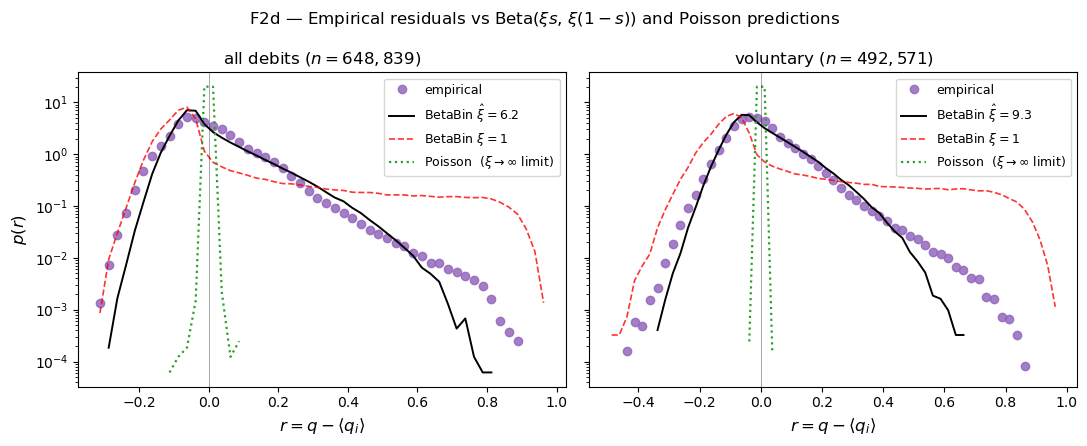

In [13]:
def simulate_residuals_beta(account_ids, s_per_account, xi, seed=42):
    """For each transaction, draw q ~ Beta(xi*s, xi*(1-s)) and return r = q - s. (m -> infty BetaBin limit.)"""
    s = account_ids.map(s_per_account).to_numpy()
    s = np.clip(s, 1e-4, 1 - 1e-4)
    rng = np.random.default_rng(seed)
    q = rng.beta(xi * s, xi * (1 - s))
    return q - s

def simulate_residuals_poisson(account_ids, s_per_account, m_per_tx, seed=44):
    """For each transaction, draw w ~ Poisson(m_t * s_i) and return r = w/m_t - s_i."""
    s = account_ids.map(s_per_account).to_numpy()
    rng = np.random.default_rng(seed)
    lam = np.clip(m_per_tx * s, 0, None)
    w = rng.poisson(lam)
    return w / m_per_tx - s

cases = [
    ('all debits', q_all, agents['mean_frac_out_all'],       xi_all),
    ('voluntary',  q_vol, agents['mean_frac_out_voluntary'], xi_vol),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, q_series, s_series, xi_hat) in zip(axes, cases):
    mask = q_series.notna() & tx['account_id'].map(s_series).notna() & (tx['pre_balance'] > 0)
    aids = tx.loc[mask, 'account_id']
    m_t  = tx.loc[mask, 'pre_balance'].to_numpy()

    r_emp     = (q_series.loc[mask] - aids.map(s_series)).to_numpy()
    r_xihat   = simulate_residuals_beta(aids, s_series, xi_hat)
    r_xi1     = simulate_residuals_beta(aids, s_series, 1.0, seed=43)
    r_poisson = simulate_residuals_poisson(aids, s_series, m_t)

    edges = np.linspace(-1, 1, 81)
    centers = 0.5 * (edges[:-1] + edges[1:])
    for r, lbl, kw in [
        (r_emp,     'empirical',                          dict(marker='o', linestyle='', color='C4', alpha=0.85)),
        (r_xihat,   fr'BetaBin $\hat\xi={xi_hat:.1f}$',   dict(linestyle='-',  color='k',     lw=1.4)),
        (r_xi1,     r'BetaBin $\xi=1$',                   dict(linestyle='--', color='r',     lw=1.2, alpha=0.8)),
        (r_poisson, r'Poisson  ($\xi\to\infty$ limit)',   dict(linestyle=':',  color='C2',    lw=1.6)),
    ]:
        d, _ = np.histogram(r, bins=edges, density=True)
        # mask zero bins so log-scale doesn't drop the line
        d = np.where(d > 0, d, np.nan)
        ax.plot(centers, d, label=lbl, **kw)
    ax.axvline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_yscale('log')
    ax.set_title(f'{label} ($n={mask.sum():,}$)')
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle('F2d — Empirical residuals vs Beta($\\xi s$, $\\xi(1-s)$) and Poisson predictions')
fig.tight_layout()

## F2e — Spitball: alternative shapes for $q \mid s_i$

Simple [0,1]-supported distributions calibrated to the **same per-account variance** as BetaBin $\hat\xi$, namely $s_i(1-s_i)/(\hat\xi+1)$, so all four model curves have matched width and we're comparing only shape.

- **Truncated Gaussian**: $q = \mathrm{clip}\big(\mathcal{N}(s_i,\, \sigma_i^2),\, 0, 1\big)$ with $\sigma_i^2 = s_i(1-s_i)/(\hat\xi+1)$. Symmetric, Gaussian tails — typically too thin for empirical financial data.
- **Truncated Laplace**: $q = \mathrm{clip}\big(s_i + \mathrm{Laplace}(0, b_i),\, 0, 1\big)$ with $b_i = \sqrt{s_i(1-s_i)/(2(\hat\xi+1))}$. Symmetric exponential tails — directly tests your visual.
- **Logit-normal**: $q = \mathrm{sigmoid}\big(\mathcal{N}(\mathrm{logit}\,s_i,\, \tau_i^2)\big)$ with $\tau_i^2 = 1/[(\hat\xi+1) s_i(1-s_i)]$ (delta-method calibration). Mildly skewed; would let you push variance into a Gaussian on the log-odds scale, which might give cleaner integrals for $P(m)$ and $P(w)$ than the BetaBin route.

If one of these visibly tracks the empirical curve in shape (not just width), it's a candidate to swap in for the BetaBin step in the generative model — though the analytical convolutions to recover $P(w)$ would have to be redone, and only the logit-normal has an obvious path there (Gaussian sums on the log-odds scale).

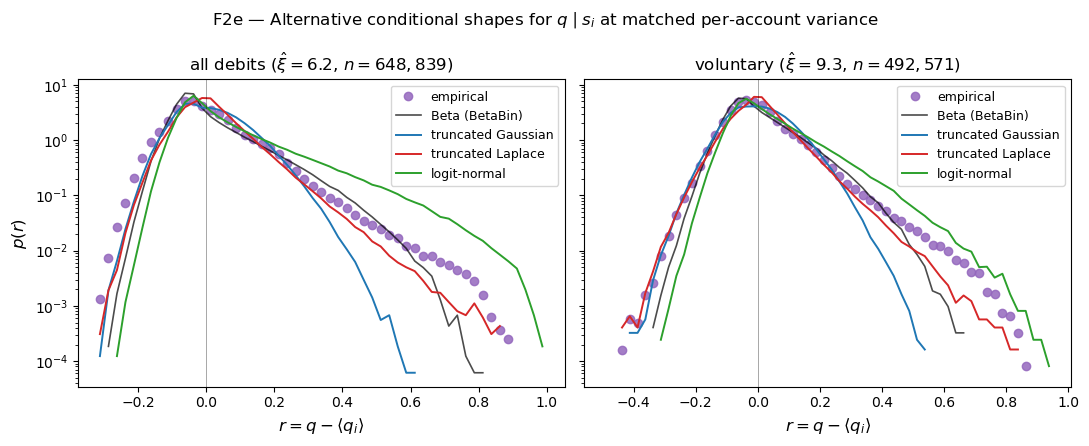

In [14]:
def _s_array(account_ids, s_per_account):
    s = account_ids.map(s_per_account).to_numpy()
    return np.clip(s, 1e-4, 1 - 1e-4)

def simulate_residuals_truncnorm(account_ids, s_per_account, xi, seed=51):
    s = _s_array(account_ids, s_per_account)
    sigma = np.sqrt(s * (1 - s) / (xi + 1))
    rng = np.random.default_rng(seed)
    q = np.clip(rng.normal(s, sigma), 0, 1)
    return q - s

def simulate_residuals_laplace(account_ids, s_per_account, xi, seed=52):
    s = _s_array(account_ids, s_per_account)
    b = np.sqrt(s * (1 - s) / (2 * (xi + 1)))
    rng = np.random.default_rng(seed)
    q = np.clip(rng.laplace(s, b), 0, 1)
    return q - s

def simulate_residuals_logitnormal(account_ids, s_per_account, xi, seed=53):
    s = _s_array(account_ids, s_per_account)
    tau = 1.0 / np.sqrt((xi + 1) * s * (1 - s))
    rng = np.random.default_rng(seed)
    z = rng.normal(np.log(s / (1 - s)), tau)
    q = 1.0 / (1.0 + np.exp(-z))
    return q - s

cases = [
    ('all debits', q_all, agents['mean_frac_out_all'],       xi_all),
    ('voluntary',  q_vol, agents['mean_frac_out_voluntary'], xi_vol),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, q_series, s_series, xi_hat) in zip(axes, cases):
    mask = q_series.notna() & tx['account_id'].map(s_series).notna()
    aids = tx.loc[mask, 'account_id']

    r_emp     = (q_series.loc[mask] - aids.map(s_series)).to_numpy()
    r_beta    = simulate_residuals_beta(aids, s_series, xi_hat)
    r_norm    = simulate_residuals_truncnorm(aids, s_series, xi_hat)
    r_lap     = simulate_residuals_laplace(aids, s_series, xi_hat)
    r_logitn  = simulate_residuals_logitnormal(aids, s_series, xi_hat)

    edges = np.linspace(-1, 1, 81)
    centers = 0.5 * (edges[:-1] + edges[1:])
    for r, lbl, kw in [
        (r_emp,    'empirical',         dict(marker='o', linestyle='', color='C4', alpha=0.85)),
        (r_beta,   r'Beta (BetaBin)',   dict(linestyle='-',  color='k',  lw=1.2, alpha=0.7)),
        (r_norm,   'truncated Gaussian',dict(linestyle='-',  color='C0', lw=1.4)),
        (r_lap,    'truncated Laplace', dict(linestyle='-',  color='C3', lw=1.4)),
        (r_logitn, 'logit-normal',      dict(linestyle='-',  color='C2', lw=1.4)),
    ]:
        d, _ = np.histogram(r, bins=edges, density=True)
        d = np.where(d > 0, d, np.nan)
        ax.plot(centers, d, label=lbl, **kw)
    ax.axvline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_yscale('log')
    ax.set_title(f'{label} ($\\hat\\xi={xi_hat:.1f}$, $n={mask.sum():,}$)')
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle('F2e — Alternative conditional shapes for $q \\mid s_i$ at matched per-account variance')
fig.tight_layout()

## F2f — Each distribution fit individually

Each candidate gets its own free parameter, estimated from the data:

| family | parametrization | fit rule (center fixed at $s_i$ or $\mathrm{logit}\,s_i$) | implied $\mathrm{Var}(q\mid i)$ |
|---|---|---|---|
| Beta | $\mathrm{Beta}(\xi s_i,\, \xi(1-s_i))$ | MLE: minimize $-\sum_{ij}\log p_{\mathrm{Beta}}$ in $\xi$ | $s_i(1-s_i)/(\xi+1)$ |
| Truncated Gaussian (clipped) | $\mathcal{N}(s_i, \sigma^2)$ on $[0,1]$ | MLE: $\hat\sigma^2 = \overline{(q-s_i)^2}$ | $\sigma^2$ (constant, approx) |
| Truncated Laplace (proper) | $\mathrm{Laplace}(s_i, b)$ renormalized to $[0,1]$ | MLE on truncated density | depends on $s_i$ via the normalizer |
| Logit-normal | $\mathrm{logit}(q) \sim \mathcal{N}(\mathrm{logit}\,s_i, \tau^2)$ | q-moment match: $\hat\tau^2 = \mathbb{E}_i[\mathrm{Var}(q\mid i)] / \mathbb{E}_i[(s_i(1-s_i))^2]$ | $\tau^2 \cdot [s_i(1-s_i)]^2$ |

Note the rightmost column: Beta and logit-normal have variance that *depends* on $s_i$ (linearly in $s(1-s)$ for Beta, quadratically for logit-normal). The truncated Gaussian and Laplace impose constant within-account variance.

The truncated Laplace is done *properly* — the density is renormalized to integrate to 1 over [0,1], and the MLE accounts for that. Visually this absorbs the boundary effects smoothly (no pile-up at 0 or 1) while keeping the exponential decay shape around $s_i$.

For logit-normal we use a q-scale moment match rather than the more obvious L2-in-logit MLE — the latter is dominated by accounts with $s_i$ near 0 or 1 where the logit transform amplifies tail values, producing an over-extreme $\hat\tau$.

all debits:  beta xi=4.49   trunc-norm sigma=0.1105   trunc-laplace b=0.1039   logit-normal tau=1.166


voluntary:  beta xi=10.53   trunc-norm sigma=0.1035   trunc-laplace b=0.0925   logit-normal tau=0.875


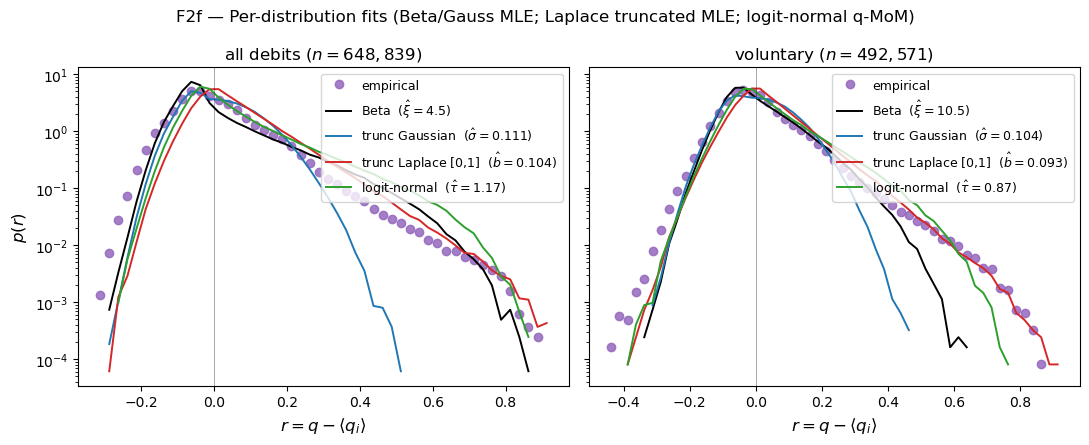

In [15]:
from scipy.optimize import minimize_scalar
from scipy.stats import beta as _beta_dist, laplace as _laplace_dist

def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def fit_xi_beta(q, s, init=5.0):
    s = np.clip(s, 1e-4, 1 - 1e-4)
    q = np.clip(q, 1e-6, 1 - 1e-6)
    def nll(log_xi):
        xi = np.exp(log_xi)
        return -_beta_dist.logpdf(q, xi * s, xi * (1 - s)).sum()
    res = minimize_scalar(nll, bracket=(np.log(0.5), np.log(init), np.log(50)), method='brent')
    return float(np.exp(res.x))

def fit_b_trunclaplace(q, s, init=0.08):
    """MLE for b in Laplace(s_i, b) renormalized to [0,1]."""
    s_clip = np.clip(s, 1e-4, 1 - 1e-4)
    def nll(log_b):
        b = np.exp(log_b)
        log_p = _laplace_dist.logpdf(q, s_clip, b)
        Z = _laplace_dist.cdf(1, s_clip, b) - _laplace_dist.cdf(0, s_clip, b)
        return -(log_p - np.log(Z)).sum()
    res = minimize_scalar(nll, bracket=(np.log(0.005), np.log(init), np.log(0.5)), method='brent')
    return float(np.exp(res.x))

def fit_logitnormal_qmom(q, s, aids, min_n=20):
    df = pd.DataFrame({'q': q, 's': s, 'aid': aids})
    g = df.groupby('aid')
    var_per = g['q'].var()
    n_per   = g.size()
    s_per   = g['s'].first()
    keep = n_per >= min_n
    e_var = np.average(var_per[keep],                     weights=n_per[keep])
    e_x2  = np.average(((s_per * (1 - s_per))**2)[keep], weights=n_per[keep])
    return float(np.sqrt(e_var / e_x2))

def fit_all(q_obs, s_obs, aids):
    r = q_obs - s_obs
    sigma_n = float(np.sqrt(np.mean(r**2)))
    b_lap   = fit_b_trunclaplace(q_obs, s_obs)
    tau_ln  = fit_logitnormal_qmom(q_obs, s_obs, aids)
    xi_b    = fit_xi_beta(q_obs, s_obs)
    return {'beta_xi': xi_b, 'norm_sigma': sigma_n, 'lap_b': b_lap, 'logitn_tau': tau_ln}

def sim_norm(s, sigma, seed):
    rng = np.random.default_rng(seed)
    return np.clip(rng.normal(s, sigma), 0, 1) - s

def sim_trunclap(s, b, seed):
    """Sample from Laplace(s_i, b) renormalized to [0,1]."""
    s_clip = np.clip(s, 1e-4, 1 - 1e-4)
    rng = np.random.default_rng(seed)
    F0 = _laplace_dist.cdf(0, s_clip, b)
    F1 = _laplace_dist.cdf(1, s_clip, b)
    u = rng.uniform(F0, F1)
    return _laplace_dist.ppf(u, s_clip, b) - s

def sim_logitn(s, tau, seed):
    rng = np.random.default_rng(seed)
    z = rng.normal(_logit(s), tau)
    return 1.0 / (1.0 + np.exp(-z)) - s

cases = [
    ('all debits', q_all, agents['mean_frac_out_all']),
    ('voluntary',  q_vol, agents['mean_frac_out_voluntary']),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, q_series, s_series) in zip(axes, cases):
    mask = q_series.notna() & tx['account_id'].map(s_series).notna()
    aids = tx.loc[mask, 'account_id']
    s_obs = aids.map(s_series).to_numpy()
    s_obs_clip = np.clip(s_obs, 1e-4, 1 - 1e-4)
    q_obs = q_series.loc[mask].to_numpy()
    q_obs_clip = np.clip(q_obs, 1e-6, 1 - 1e-6)
    r_emp = q_obs - s_obs

    fits = fit_all(q_obs_clip, s_obs_clip, aids.to_numpy())
    print(f"{label}:  beta xi={fits['beta_xi']:.2f}   trunc-norm sigma={fits['norm_sigma']:.4f}   "
          f"trunc-laplace b={fits['lap_b']:.4f}   logit-normal tau={fits['logitn_tau']:.3f}")

    rng_master = np.random.default_rng(60)
    seeds = rng_master.integers(0, 2**31, size=4)
    r_beta   = simulate_residuals_beta(aids, s_series, fits['beta_xi'], seed=int(seeds[0]))
    r_norm   = sim_norm(s_obs_clip,    fits['norm_sigma'], int(seeds[1]))
    r_lap    = sim_trunclap(s_obs_clip, fits['lap_b'],     int(seeds[2]))
    r_logitn = sim_logitn(s_obs_clip,   fits['logitn_tau'], int(seeds[3]))

    edges = np.linspace(-1, 1, 81)
    centers = 0.5 * (edges[:-1] + edges[1:])
    for r, lbl, kw in [
        (r_emp,    'empirical',                                                 dict(marker='o', linestyle='', color='C4', alpha=0.85)),
        (r_beta,   fr"Beta  ($\hat\xi={fits['beta_xi']:.1f}$)",                  dict(linestyle='-', color='k',  lw=1.4)),
        (r_norm,   fr"trunc Gaussian  ($\hat\sigma={fits['norm_sigma']:.3f}$)",  dict(linestyle='-', color='C0', lw=1.4)),
        (r_lap,    fr"trunc Laplace [0,1]  ($\hat b={fits['lap_b']:.3f}$)",      dict(linestyle='-', color='C3', lw=1.4)),
        (r_logitn, fr"logit-normal  ($\hat\tau={fits['logitn_tau']:.2f}$)",      dict(linestyle='-', color='C2', lw=1.4)),
    ]:
        d, _ = np.histogram(r, bins=edges, density=True)
        d = np.where(d > 0, d, np.nan)
        ax.plot(centers, d, label=lbl, **kw)
    ax.axvline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_yscale('log')
    ax.set_title(f'{label} ($n={mask.sum():,}$)')
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle('F2f — Per-distribution fits (Beta/Gauss MLE; Laplace truncated MLE; logit-normal q-MoM)')
fig.tight_layout()

## F2g — Per-account variance scaling for each fitted distribution

The same per-account scatter as F2c, but now overlaid with the variance prediction of each MLE-fit family. On log-log axes each model has a characteristic slope:

- **Beta** predicts $\mathrm{Var}(q\mid i) = s_i(1-s_i)/(\hat\xi+1)$ — a line of slope 1.
- **Truncated Gaussian** predicts $\mathrm{Var}(q\mid i) \approx \hat\sigma^2$ — flat, slope 0.
- **Truncated Laplace** predicts $\mathrm{Var}(q\mid i) \approx 2\hat b^2$ — also flat.
- **Logit-normal** predicts $\mathrm{Var}(q\mid i) \approx \hat\tau^2 \cdot [s_i(1-s_i)]^2$ (delta-method) — slope 2.

So the empirical cloud's slope on log-log directly tells us which functional form has the right s-dependence, independent of the absolute level.

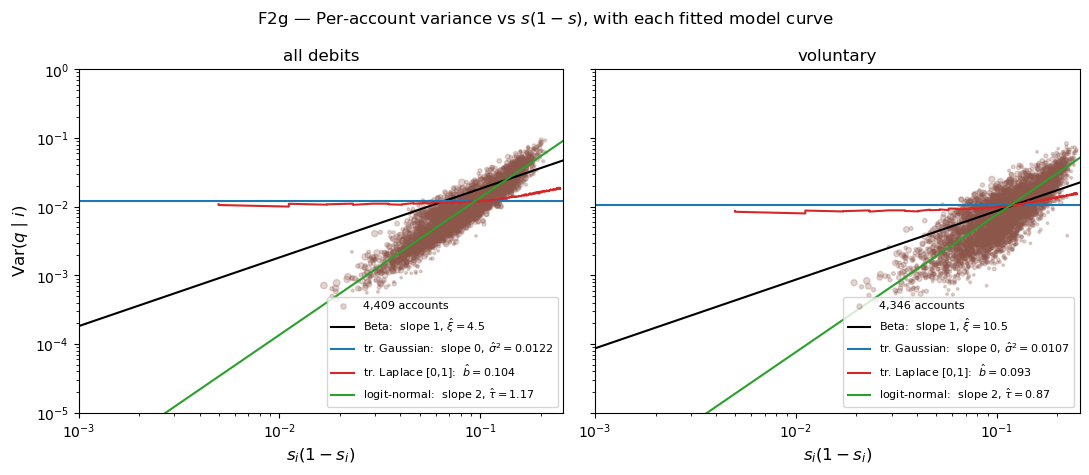

In [16]:
def fit_for_case(q_series, s_series, account_ids):
    mask = q_series.notna() & account_ids.map(s_series).notna()
    q_obs = np.clip(q_series.loc[mask].to_numpy(),                     1e-6, 1 - 1e-6)
    s_obs = np.clip(account_ids.loc[mask].map(s_series).to_numpy(),    1e-4, 1 - 1e-4)
    aids  = account_ids.loc[mask].to_numpy()
    return fit_all(q_obs, s_obs, aids)

def trunclaplace_var_curve(b, s_grid, n_samples=20000, seed=99):
    """Numerical Var(q | s, b) for Laplace(s, b) renormalized to [0,1], over a grid of s."""
    rng = np.random.default_rng(seed)
    s_grid = np.asarray(s_grid)
    s_col = s_grid[:, None]
    F0 = _laplace_dist.cdf(0, s_col, b)
    F1 = _laplace_dist.cdf(1, s_col, b)
    u = F0 + rng.uniform(0, 1, size=(len(s_grid), n_samples)) * (F1 - F0)
    q = _laplace_dist.ppf(u, s_col, b)
    return np.var(q, axis=1)

cases = [
    ('all debits', q_all, agents['mean_frac_out_all'],       pa_all),
    ('voluntary',  q_vol, agents['mean_frac_out_voluntary'], pa_vol),
]

xx = np.geomspace(1e-3, 0.26, 200)
s_grid = np.concatenate([np.linspace(0.005, 0.5, 80), np.linspace(0.5, 0.995, 80)])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, (label, q_series, s_series, pa) in zip(axes, cases):
    fits = fit_for_case(q_series, s_series, tx['account_id'])
    xi, sig, b, tau = fits['beta_xi'], fits['norm_sigma'], fits['lap_b'], fits['logitn_tau']

    x = (pa['s'] * (1 - pa['s'])).to_numpy()
    y = pa['var'].to_numpy()
    ax.scatter(x, y, s=2 + 0.05*pa['n'], alpha=0.25, color='C5', label=f'{len(pa):,} accounts')

    ax.plot(xx, xx / (xi + 1),               color='k',  lw=1.5, label=fr'Beta:  slope 1, $\hat\xi={xi:.1f}$')
    ax.plot(xx, np.full_like(xx, sig**2),    color='C0', lw=1.5, label=fr'tr. Gaussian:  slope 0, $\hat\sigma^2={sig**2:.4f}$')
    var_lap = trunclaplace_var_curve(b, s_grid)
    x_lap   = s_grid * (1 - s_grid)
    order   = np.argsort(x_lap)
    ax.plot(x_lap[order], var_lap[order],    color='C3', lw=1.5, label=fr'tr. Laplace [0,1]:  $\hat b={b:.3f}$')
    ax.plot(xx, tau**2 * xx**2,              color='C2', lw=1.5, label=fr'logit-normal:  slope 2, $\hat\tau={tau:.2f}$')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$s_i(1-s_i)$')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(1e-5, 1)
    ax.set_title(label)
    ax.legend(loc='lower right', fontsize=8)
axes[0].set_ylabel(r'$\mathrm{Var}(q \mid i)$')
fig.suptitle('F2g — Per-account variance vs $s(1-s)$, with each fitted model curve')
fig.tight_layout()